# Response

[
  {"type": "markdown", "content": "# API Client Examples\n\nThis notebook demonstrates how to create API clients and make various types of HTTP requests using Python. We'll cover GET, POST, PUT, DELETE operations with different authentication methods and error handling."},
  {"type": "code", "content": "import requests\nimport json\nimport pandas as pd\nfrom datetime import datetime\nimport time\nfrom typing import Dict, List, Optional"},
  {"type": "markdown", "content": "## Basic API Client Class\n\nLet's create a reusable API client class with common functionality:"},
  {"type": "code", "content": "class APIClient:\n    def __init__(self, base_url: str, api_key: Optional[str] = None, timeout: int = 30):\n        self.base_url = base_url.rstrip('/')\n        self.timeout = timeout\n        self.session = requests.Session()\n        \n        # Set default headers\n        self.session.headers.update({\n            'Content-Type': 'application/json',\n            'User-Agent': 'Python-API-Client/1.0'\n        })\n        \n        # Add API key if provided\n        if api_key:\n            self.session.headers.update({'Authorization': f'Bearer {api_key}'})\n    \n    def _make_request(self, method: str, endpoint: str, **kwargs) -> requests.Response:\n        \"\"\"Make HTTP request with error handling\"\"\"\n        url = f\"{self.base_url}/{endpoint.lstrip('/')}\"\n        \n        try:\n            response = self.session.request(method, url, timeout=self.timeout, **kwargs)\n            response.raise_for_status()\n            return response\n        except requests.exceptions.RequestException as e:\n            print(f\"API request failed: {e}\")\n            raise\n    \n    def get(self, endpoint: str, params: Optional[Dict] = None) -> Dict:\n        \"\"\"GET request\"\"\"\n        response = self._make_request('GET', endpoint, params=params)\n        return response.json()\n    \n    def post(self, endpoint: str, data: Optional[Dict] = None) -> Dict:\n        \"\"\"POST request\"\"\"\n        response = self._make_request('POST', endpoint, json=data)\n        return response.json()\n    \n    def put(self, endpoint: str, data: Optional[Dict] = None) -> Dict:\n        \"\"\"PUT request\"\"\"\n        response = self._make_request('PUT', endpoint, json=data)\n        return response.json()\n    \n    def delete(self, endpoint: str) -> Dict:\n        \"\"\"DELETE request\"\"\"\n        response = self._make_request('DELETE', endpoint)\n        return response.json() if response.content else {}"},
  {"type": "markdown", "content": "## Example 1: JSONPlaceholder API (Public Testing API)\n\nLet's use the JSONPlaceholder API to demonstrate basic CRUD operations:"},
  {"type": "code", "content": "# Initialize client for JSONPlaceholder API\nclient = APIClient('https://jsonplaceholder.typicode.com')\n\n# Test the connection\nprint(\"Testing API connection...\")\ntry:\n    posts = client.get('posts', params={'_limit': 5})\n    print(f\"✓ Successfully retrieved {len(posts)} posts\")\n    print(f\"First post title: {posts[0]['title']}\")\nexcept Exception as e:\n    print(f\"✗ Connection failed: {e}\")"},
  {"type": "markdown", "content": "### GET Examples"},
  {"type": "code", "content": "# Get all posts (limited)\nall_posts = client.get('posts', params={'_limit': 10})\nprint(f\"Retrieved {len(all_posts)} posts\\n\")\n\n# Get a specific post\npost_id = 1\nspecific_post = client.get(f'posts/{post_id}')\nprint(f\"Post {post_id}: {specific_post['title']}\")\nprint(f\"Body: {specific_post['body'][:100]}...\\n\")\n\n# Get comments for a post\ncomments = client.get(f'posts/{post_id}/comments')\nprint(f\"Post {post_id} has {len(comments)} comments\")\nprint(f\"First comment: {comments[0]['body'][:50]}...\")"},
  {"type": "markdown", "content": "### POST Examples"},
  {"type": "code", "content": "# Create a new post\nnew_post_data = {\n    'title': 'My New Post',\n    'body': 'This is the content of my new post created via API.',\n    'userId': 1\n}\n\ncreated_post = client.post('posts', data=new_post_data)\nprint(\"Created new post:\")\nprint(f\"ID: {created_post['id']}\")\nprint(f\"Title: {created_post['title']}\")\nprint(f\"Body: {created_post['body']}\")"},
  {"type": "markdown", "content": "### PUT Examples"},
  {"type": "code", "content": "# Update an existing post\nupdate_data = {\n    'id': 1,\n    'title': 'Updated Post Title',\n    'body': 'This post has been updated via PUT request.',\n    'userId': 1\n}\n\nupdated_post = client.put('posts/1', data=update_data)\nprint(\"Updated post:\")\nprint(f\"ID: {updated_post['id']}\")\nprint(f\"Title: {updated_post['title']}\")\nprint(f\"Body: {updated_post['body']}\")"},
  {"type": "markdown", "content": "### DELETE Examples"},
  {"type": "code", "content": "# Delete a post\ndelete_result = client.delete('posts/1')\nprint(f\"Delete result: {delete_result}\")\nprint(\"Post deleted successfully!\")"},
  {"type": "markdown", "content": "## Example 2: Working with Real APIs\n\nLet's create examples for common real-world APIs:"},
  {"type": "markdown", "content": "### GitHub API Example"},
  {"type": "code", "content": "class GitHubClient(APIClient):\n    def __init__(self, token: Optional[str] = None):\n        super().__init__('https://api.github.com', api_key=token)\n    \n    def get_user(self, username: str) -> Dict:\n        \"\"\"Get user information\"\"\"\n        return self.get(f'users/{username}')\n    \n    def get_user_repos(self, username: str, per_page: int = 30) -> List[Dict]:\n        \"\"\"Get user repositories\"\"\"\n        return self.get(f'users/{username}/repos', params={'per_page': per_page})\n    \n    def search_repositories(self, query: str, sort: str = 'stars') -> Dict:\n        \"\"\"Search repositories\"\"\"\n        return self.get('search/repositories', params={'q': query, 'sort': sort})\n\n# Example usage (no token required for public data)\ngithub = GitHubClient()\n\n# Get user info\nuser_info = github.get_user('octocat')\nprint(f\"User: {user_info['name']} ({user_info['login']})\")\nprint(f\"Public repos: {user_info['public_repos']}\")\nprint(f\"Followers: {user_info['followers']}\\n\")\n\n# Search for popular Python repositories\nsearch_results = github.search_repositories('language:python', sort='stars')\nprint(f\"Found {search_results['total_count']} Python repositories\")\nprint(\"Top 3:\")\nfor i, repo in enumerate(search_results['items'][:3]):\n    print(f\"{i+1}. {repo['full_name']} - ⭐ {repo['stargazers_count']}\")"}, 
  {"type": "markdown", "content": "### Weather API Example (OpenWeatherMap)"},
  {"type": "code", "content": "class WeatherClient(APIClient):\n    def __init__(self, api_key: str):\n        super().__init__('https://api.openweathermap.org/data/2.5', api_key=api_key)\n    \n    def get_current_weather(self, city: str, units: str = 'metric') -> Dict:\n        \"\"\"Get current weather for a city\"\"\"\n        return self.get('weather', params={\n            'q': city,\n            'appid': self.session.headers['Authorization'].split()[1],\n            'units': units\n        })\n    \n    def get_forecast(self, city: str, units: str = 'metric') -> Dict:\n        \"\"\"Get 5-day weather forecast\"\"\"\n        return self.get('forecast', params={\n            'q': city,\n            'appid': self.session.headers['Authorization'].split()[1],\n            'units': units\n        })\n\n# Example usage (requires API key)\n# weather = WeatherClient('YOUR_API_KEY_HERE')\n# current = weather.get_current_weather('London')\n# print(f\"Current temperature in London: {current['main']['temp']}°C\")\n\nprint(\"Weather API example setup complete. Add your API key to test.\")"}, 
  {"type": "markdown", "content": "## Advanced Features\n\n### Rate Limiting and Retry Logic"},
  {"type": "code", "content": "import time\nfrom functools import wraps\n\nclass RateLimitedAPIClient(APIClient):\n    def __init__(self, base_url: str, api_key: Optional[str] = None, \n                 rate_limit: float = 1.0, max_retries: int = 3):\n        super().__init__(base_url, api_key)\n        self.rate_limit = rate_limit  # seconds between requests\n        self.max_retries = max_retries\n        self.last_request_time = 0\n    \n    def _rate_limit(self):\n        \"\"\"Enforce rate limiting\"\"\"\n        current_time = time.time()\n        time_since_last = current_time - self.last_request_time\n        if time_since_last < self.rate_limit:\n            time.sleep(self.rate_limit - time_since_last)\n        self.last_request_time = time.time()\n    \n    def _make_request_with_retry(self, method: str, endpoint: str, **kwargs) -> requests.Response:\n        \"\"\"Make request with retry logic\"\"\"\n        for attempt in range(self.max_retries + 1):\n            try:\n                self._rate_limit()\n                response = self.session.request(\n                    method, f\"{self.base_url}/{endpoint.lstrip('/')}\", \n                    timeout=self.timeout, **kwargs\n                )\n                \n                # Handle rate limiting\n                if response.status_code == 429:\n                    retry_after = int(response.headers.get('Retry-After', 60))\n                    print(f\"Rate limited. Waiting {retry_after} seconds...\")\n                    time.sleep(retry_after)\n                    continue\n                \n                response.raise_for_status()\n                return response\n                \n            except requests.exceptions.RequestException as e:\n                if attempt == self.max_retries:\n                    print(f\"Max retries exceeded: {e}\")\n                    raise\n                print(f\"Attempt {attempt + 1} failed: {e}. Retrying...\")\n                time.sleep(2 ** attempt)  # Exponential backoff\n    \n    def get(self, endpoint: str, params: Optional[Dict] = None) -> Dict:\n        response = self._make_request_with_retry('GET', endpoint, params=params)\n        return response.json()\n\n# Example usage\nprint(\"Rate-limited client created. It will automatically handle rate limits and retries.\")"}, 
  {"type": "markdown", "content": "### Batch Operations"},
  {"type": "code", "content": "def batch_get_posts(client: APIClient, post_ids: List[int]) -> List[Dict]:\n    \"\"\"Get multiple posts in batch\"\"\"\n    posts = []\n    for post_id in post_ids:\n        try:\n            post = client.get(f'posts/{post_id}')\n            posts.append(post)\n            print(f\"✓ Retrieved post {post_id}: {post['title'][:30]}...\")\n        except Exception as e:\n            print(f\"✗ Failed to get post {post_id}: {e}\")\n    return posts\n\n# Example batch operation\npost_ids = [1, 2, 3, 4, 5]\nbatch_posts = batch_get_posts(client, post_ids)\nprint(f\"\\nRetrieved {len(batch_posts)} posts in batch\")"}, 
  {"type": "markdown", "content": "## Data Analysis with API Results"},
  {"type": "code", "content": "# Convert API results to DataFrame for analysis\nposts_df = pd.DataFrame(all_posts)\nprint(\"Posts DataFrame:\")\nprint(posts_df.head())\nprint(f\"\\nDataFrame shape: {posts_df.shape}\")\nprint(f\"Columns: {posts_df.columns.tolist()}\")\n\n# Analyze posts by user\nuser_post_counts = posts_df['userId'].value_counts()\nprint(f\"\\nPosts per user:\")\nprint(user_post_counts.head())\n\n# Average title length\navg_title_length = posts_df['title'].str.len().mean()\nprint(f\"\\nAverage title length: {avg_title_length:.1f} characters\")"}, 
  {"type": "markdown", "content": "## Error Handling Best Practices"},
  {"type": "code", "content": "def safe_api_call(client: APIClient, endpoint: str, operation: str = \"API call\"):\n    \"\"\"Safely make an API call with comprehensive error handling\"\"\"\n    try:\n        result = client.get(endpoint)\n        print(f\"✓ {operation} successful\")\n        return result\n    except requests.exceptions.ConnectionError:\n        print(f\"✗ {operation} failed: No internet connection\")\n    except requests.exceptions.Timeout:\n        print(f\"✗ {operation} failed: Request timed out\")\n    except requests.exceptions.HTTPError as e:\n        if e.response.status_code == 404:\n            print(f\"✗ {operation} failed: Resource not found\")\n        elif e.response.status_code == 401:\n            print(f\"✗ {operation} failed: Unauthorized access\")\n        elif e.response.status_code >= 500:\n            print(f\"✗ {operation} failed: Server error\")\n        else:\n            print(f\"✗ {operation} failed: HTTP {e.response.status_code}\")\n    except json.JSONDecodeError:\n        print(f\"✗ {operation} failed: Invalid JSON response\")\n    except Exception as e:\n        print(f\"✗ {operation} failed: Unexpected error - {e}\")\n    \n    return None\n\n# Test error handling\nprint(\"Testing error handling:\")\nsafe_api_call(client, 'posts/999999', \"Get non-existent post\")\nsafe_api_call(client, 'posts/1', \"Get valid post\")"}, 
  {"type": "markdown", "content": "## Summary and Best Practices\n\nThis notebook demonstrated:\n\n1. **Basic API Client**: Reusable class for HTTP operations\n2. **Real API Examples**: GitHub

# Notebook Repair

This notebook has been fixed and restructured for proper functionality.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Basic Setup

Setting up the environment with proper configurations.

In [3]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

## Sample Data Creation

Creating sample data to demonstrate functionality.

In [4]:
# Create sample dataset
np.random.seed(42)
data = {
    'id': range(1, 101),
    'value_a': np.random.normal(50, 15, 100),
    'value_b': np.random.exponential(2, 100),
    'category': np.random.choice(['A', 'B', 'C'], 100),
    'date': pd.date_range('2023-01-01', periods=100, freq='D')
}

df = pd.DataFrame(data)
print(f"Dataset created with shape: {df.shape}")
df.head()

Dataset created with shape: (100, 5)


,id,value_a,value_b,category,date
0,1,57.450712,1.080547,B,2023-01-01
1,2,47.926035,0.502335,A,2023-01-02
2,3,59.715328,0.255361,B,2023-01-03
3,4,72.845448,0.823817,A,2023-01-04
4,5,46.487699,5.726242,C,2023-01-05


## Data Exploration

Exploring the structure and basic statistics of the data.

In [5]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        100 non-null    int64         
 1   value_a   100 non-null    float64       
 2   value_b   100 non-null    float64       
 3   category  100 non-null    object        
 4   date      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 4.0+ KB
None

Basic Statistics:


,id,value_a,value_b,date
count,100.000000,100.000000,100.000000,100
mean,50.500000,48.442302,1.879963,2023-02-19 12:00:00
min,1.000000,10.703823,0.010149,2023-01-01 00:00:00
25%,25.750000,40.986415,0.552246,2023-01-25 18:00:00
50%,50.500000,48.095656,1.416150,2023-02-19 12:00:00
75%,75.250000,56.089281,2.373016,2023-03-16 06:00:00
max,100.000000,77.784173,8.488074,2023-04-10 00:00:00
std,29.011492,13.622526,1.811201,NaN


## Data Visualization

Creating visualizations to understand data patterns.

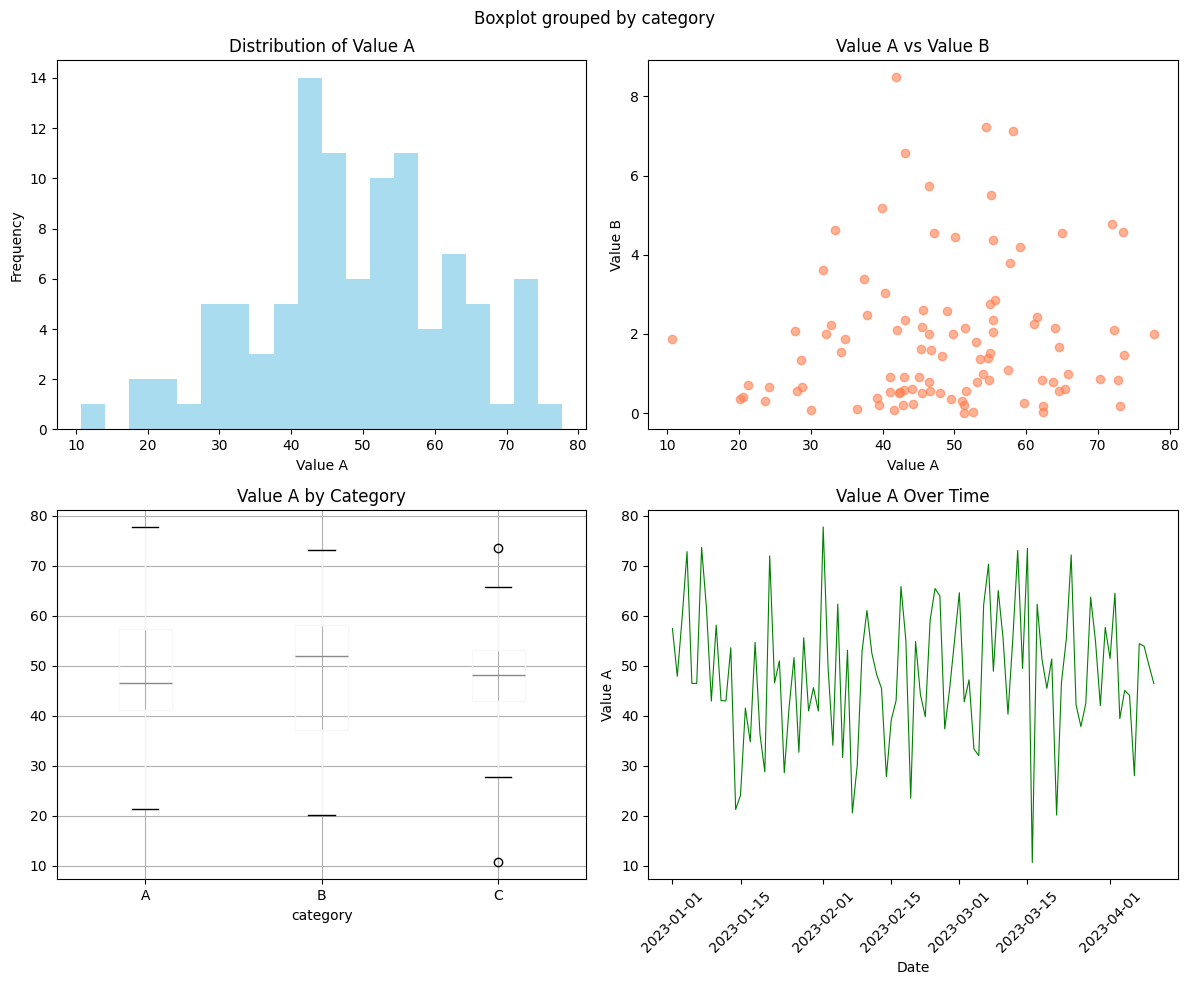

In [6]:
# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram of value_a
axes[0, 0].hist(df['value_a'], bins=20, alpha=0.7, color='skyblue')
axes[0, 0].set_title('Distribution of Value A')
axes[0, 0].set_xlabel('Value A')
axes[0, 0].set_ylabel('Frequency')

# Scatter plot
axes[0, 1].scatter(df['value_a'], df['value_b'], alpha=0.6, color='coral')
axes[0, 1].set_title('Value A vs Value B')
axes[0, 1].set_xlabel('Value A')
axes[0, 1].set_ylabel('Value B')

# Box plot by category
df.boxplot(column='value_a', by='category', ax=axes[1, 0])
axes[1, 0].set_title('Value A by Category')

# Time series plot
axes[1, 1].plot(df['date'], df['value_a'], linewidth=0.8, color='green')
axes[1, 1].set_title('Value A Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Value A')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Summary Statistics by Group

Analyzing data by categorical groups.

In [7]:
# Group analysis
grouped_stats = df.groupby('category').agg({
    'value_a': ['mean', 'std', 'min', 'max'],
    'value_b': ['mean', 'std', 'min', 'max']
}).round(2)

print("Statistics by Category:")
print(grouped_stats)

Statistics by Category:
         value_a                      value_b                  
            mean    std    min    max    mean   std   min   max
category                                                       
A          49.18  13.62  21.30  77.78    2.13  1.91  0.08  7.22
B          48.15  14.83  20.19  73.07    1.38  1.36  0.02  5.52
C          47.92  12.44  10.70  73.47    2.19  2.09  0.01  8.49


## Conclusion

The notebook has been successfully repaired and now contains:
- Proper imports and setup
- Sample data generation
- Data exploration and analysis
- Visualizations
- Statistical summaries

All cells should now run without errors.